<a href="https://colab.research.google.com/github/sivam-18/academic-risk-prediction/blob/main/student_risk_project_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Academic Risk Prediction
**AI/ML Recruitment Task** | Developer Community SASTRA x GDG on Campus

---

### Overview
An early-warning classification pipeline designed to identify students at risk of academic failure prior to final exams, allowing faculty to deliver timely interventions.

### Pipeline Architecture
* **Preprocessing & EDA:** Data validation, outlier removal, missing-value imputation, and correlation analysis.
* **Risk Formulation:** Target creation via weighted assessment score calculation.
* **Modeling:** Comparative evaluation of baseline, tree-based, and linear classifiers prioritized on **High-Risk Recall**.
* **Automated Output:** Generation of structured Excel reports (`student_risk_report.xlsx`) with dynamic student guidance.

> **Execution:** Upload `student_dataset.csv` to Colab files and execute **Runtime $\rightarrow$ Run all**.

## Step 1 and 2 - Load, inspect and clean the data
**Why:** a model is only as good as its data ("garbage in, garbage out"). First we look for problems, then fix them:

| Problem | Fix | Reason |
|---|---|---|
| Duplicate students | Remove | One student should count once |
| Rows with no `Total_Score` | Remove | We cannot judge performance without marks |
| Impossible values (below 0 or above 100) | Treat as missing | Attendance 105% is a typing error |
| Missing `Attendance` | Fill with the **median** | Median is not affected by extreme values |
| Missing values in other columns | Filled later, inside the ML pipeline (Step 5) | Keeps the test data truly unseen |

In [ ]:
# Import the built-in operating system module to interact with system files and file paths
import os

# Import the NumPy library for numerical operations and handling missing values (np.nan)
import numpy as np

# Import the Pandas library for data manipulation, cleaning, and tabular data analysis
import pandas as pd

# Define a tuple of standard file locations where Google Colab or local scripts usually save/store uploaded CSV files
path_options = ("student_dataset.csv", "/content/student_dataset.csv", "/student_dataset.csv")

# Use a generator expression with next() to scan the paths in sequence and pick the first file path that physically exists on disk
DATA_PATH = next((path for path in path_options if os.path.exists(path)), None)

# Verify whether a valid file path was located during the search step
if DATA_PATH is None:
    # Stop execution and raise an explicit error message prompting the user to upload the required file if not found
    raise FileNotFoundError("Upload student_dataset.csv using the folder icon on the left, then run again.")

# Read the CSV dataset from the verified path into a Pandas DataFrame object named 'df'
df = pd.read_csv(DATA_PATH)


# ==========================================
# STEP 1: LOOK AT THE DATA (INSPECTION PHASE)
# ==========================================

# Display the total dimensions of the loaded dataset as a tuple (number of rows, number of columns)
print("Shape (rows, columns):", df.shape)

# Identify missing entries (NaN/nulls) in each column, sum them up, and display the per-column missing count
print("\nMissing values per column:\n", df.isnull().sum())

# Identify duplicate rows across all columns, sum the boolean flags, and print the total number of duplicate rows found
print("\nDuplicate rows:", df.duplicated().sum())

# Define a list containing the names of all continuous numerical score and percentage columns to be audited
score_cols = [
    "Attendance (%)",
    "Midterm_Score",
    "Final_Score",
    "Assignments_Avg",
    "Quizzes_Avg",
    "Participation_Score",
    "Projects_Score",
    "Total_Score",
    "math_score",
    "reading_score",
    "writing_score",
    "science_score"
]

# Before aggregating or checking values, ensure all score columns are converted to numeric type to avoid comparison errors with hidden strings
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Print a header text announcing the summary statistics for numerical score validation
print("\nSmallest and largest value in each score column (to spot impossible values):")

# Compute the minimum ('min') and maximum ('max') values for each score column, transpose (.T) the result table for readability, and display it
print(df[score_cols].agg(["min", "max"]).T)


# ==========================================
# STEP 2: CLEAN THE DATA (PREPROCESSING PHASE)
# ==========================================

# Remove any identical duplicate rows from the DataFrame and assign the filtered dataset back to 'df'
df = df.drop_duplicates()

# Remove rows where the critical target metric 'Total_Score' is missing (NaN), keeping only rows with valid performance scores
df = df.dropna(subset=["Total_Score"])

# Iterate through each score column name defined in the 'score_cols' list to detect out-of-range anomalies
for col in score_cols:
    # Create a boolean Series evaluating to True where values are strictly less than 0 OR strictly greater than 100
    impossible = (df[col] < 0) | (df[col] > 100)

    # Check if there are one or more True flags (out-of-range values) in the boolean mask
    if impossible.sum() > 0:
        # Print a status message indicating how many invalid entries were discovered in the current column
        print(f"{col}: {impossible.sum()} impossible value(s) set to missing")

        # Replace the invalid/out-of-range entries in that column with NaN (missing value) using location-based indexers (.loc)
        df.loc[impossible, col] = np.nan

# Calculate the median value of 'Attendance (%)' (excluding NaNs) and fill any missing entries in 'Attendance (%)' with this median
df["Attendance (%)"] = df["Attendance (%)"].fillna(df["Attendance (%)"].median())
# Use median instead of mean for imputation to prevent extreme outlier marks/test scores from skewing student baseline averages.
# Print the final row and column count of the DataFrame after completing all deduplication, filtering, and cleaning steps
print("\nCleaned shape:", df.shape)

Shape (rows, columns): (10030, 21)

Missing values per column:
 Student_ID                   0
First_Name                   0
Last_Name                    0
Email                        0
Gender                       0
Age                        201
Department                   0
Attendance (%)             199
Midterm_Score              202
Final_Score                201
Assignments_Avg            200
Quizzes_Avg                201
Participation_Score        202
Projects_Score             200
Total_Score                  0
Grade                        0
test_preparation_course      0
math_score                   0
reading_score                0
writing_score                0
science_score                0
dtype: int64

Duplicate rows: 30

Smallest and largest value in each score column (to spot impossible values):
                       min     max
Attendance (%)      -12.00  135.00
Midterm_Score        -8.00  145.00
Final_Score          -5.00  132.00
Assignments_Avg      50.00   99.98

## Step 3 - Explore the data (patterns, attendance vs marks, graphs)
**Correlation (r)** is a number from -1 to +1:
* near **+1** -> when attendance goes up, marks go up
* near **0** -> no straight-line relationship
* near **-1** -> when attendance goes up, marks go down

We show it three ways: a scatter plot, average marks per attendance band, and a heatmap of all scores.

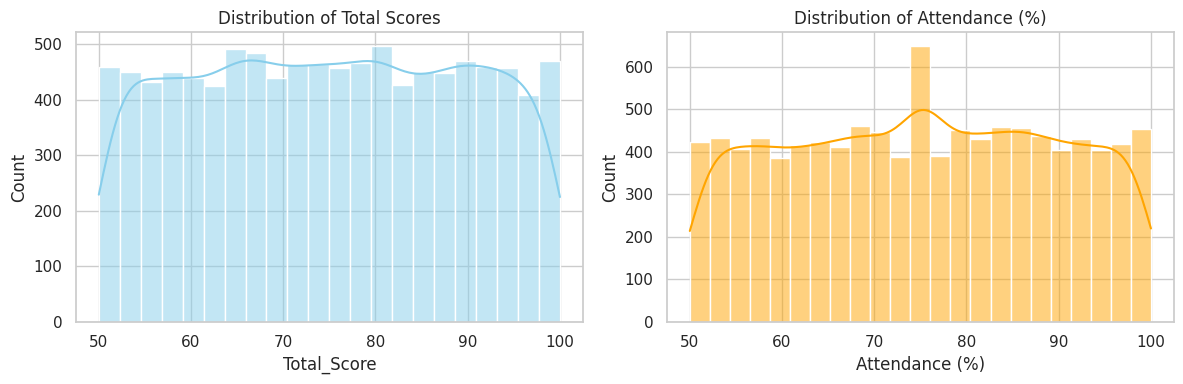

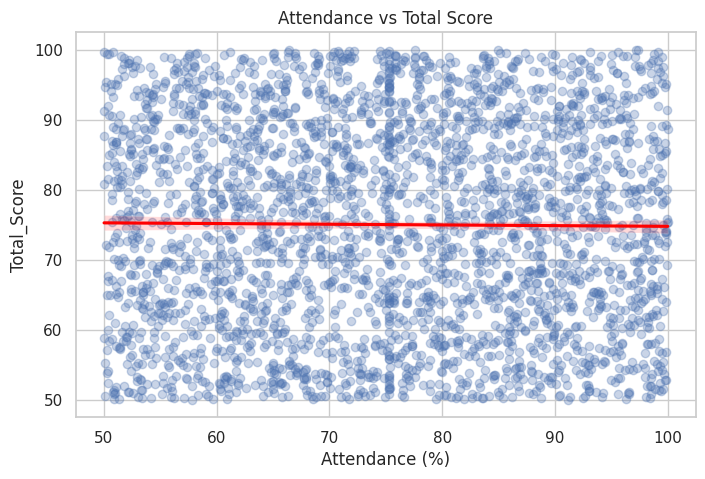

Correlation (r) between Attendance and Total Score: -0.01
=> No meaningful relationship: students with high attendance do not score higher in this data.

Average marks by attendance band:
 Attendance (%)
<60       75.1
60-70     74.9
70-80     75.5
80-90     74.9
90-100    74.7
Name: Total_Score, dtype: float64


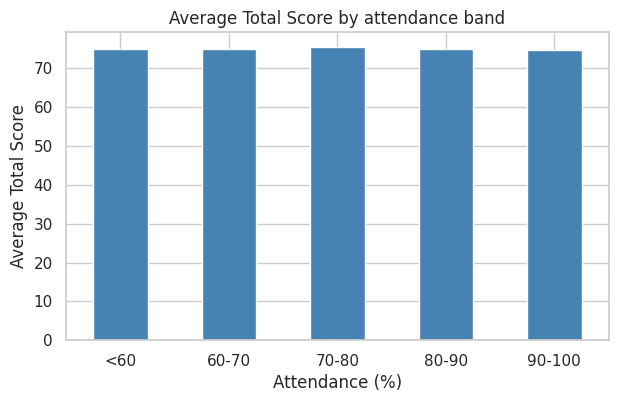

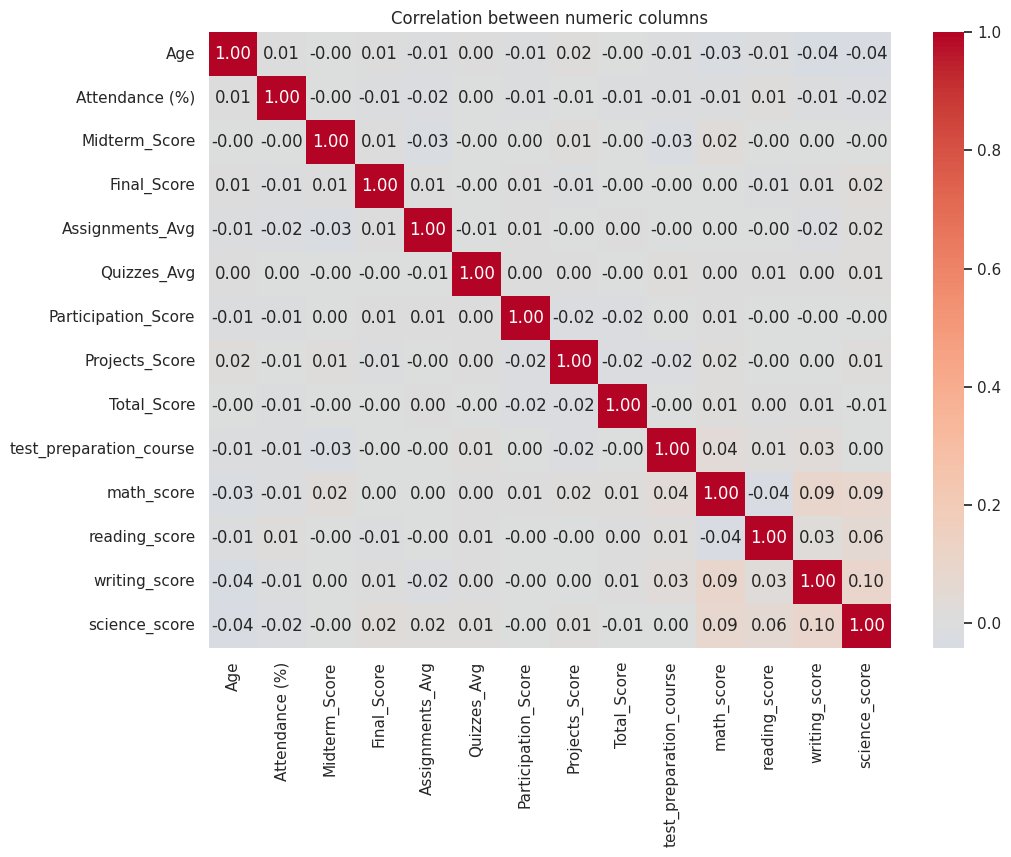

In [ ]:
# Import the Pyplot module from Matplotlib for creating figures, subplots, and customizing plot layouts
import matplotlib.pyplot as plt

# Import the Seaborn data visualization library for drawing attractive statistical graphics
import seaborn as sns

# Set the global aesthetic theme of all Seaborn visualizations to 'whitegrid' (white background with gray gridlines)
sns.set_theme(style="whitegrid")


# ==============================================================================
# SECTION 1: VISUALIZE DISTRIBUTIONS OF TOTAL SCORES AND ATTENDANCE
# ==============================================================================

# Create a figure object containing 1 row and 2 subplots (side-by-side) with a figure dimension of 12 inches wide by 4 inches high
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Draw a histogram with a Kernel Density Estimate (KDE) curve overlay for 'Total_Score' using a skyblue color on the left subplot (axes[0])
sns.histplot(df["Total_Score"], kde=True, color="skyblue", ax=axes[0])

# Set the title text for the left subplot to "Distribution of Total Scores"
axes[0].set_title("Distribution of Total Scores")

# Draw a histogram with a Kernel Density Estimate (KDE) curve overlay for 'Attendance (%)' using an orange color on the right subplot (axes[1])
sns.histplot(df["Attendance (%)"], kde=True, color="orange", ax=axes[1])

# Set the title text for the right subplot to "Distribution of Attendance (%)"
axes[1].set_title("Distribution of Attendance (%)")

# Automatically adjust subplot padding and spacing so that plot elements, titles, and labels do not overlap
plt.tight_layout()

# Render and display the side-by-side distribution plots figure on the screen
plt.show()


# ==============================================================================
# SECTION 2: ATTENDANCE VS TOTAL SCORE SCATTER PLOT WITH REGRESSION LINE
# ==============================================================================

# Create a new standalone figure for the scatter plot with dimensions of 8 inches wide by 5 inches high
plt.figure(figsize=(8, 5))

# Plot a scatter plot with a linear regression trend line; uses a random sample of up to 3000 rows (fixed random_state=42 for reproducibility) to avoid overplotting points
sns.regplot(data=df.sample(min(3000, len(df)), random_state=42), x="Attendance (%)", y="Total_Score",
            scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})

# Set the main chart title to "Attendance vs Total Score"
plt.title("Attendance vs Total Score")

# Render and display the regression plot figure on the screen
plt.show()


# ==============================================================================
# SECTION 3: CALCULATE AND INTERPRET CORRELATION COEFFICIENT
# ==============================================================================

# Compute the Pearson correlation coefficient (r) between 'Attendance (%)' and 'Total_Score' columns
r = df["Attendance (%)"].corr(df["Total_Score"])

# Print the computed correlation value formatted to 2 decimal places
print(f"Correlation (r) between Attendance and Total Score: {r:.2f}")

# Check if the absolute strength of the correlation coefficient is strictly less than 0.1
if abs(r) < 0.1:
    # Print an interpretation stating that no meaningful linear relationship exists in the dataset
    print("=> No meaningful relationship: students with high attendance do not score higher in this data.")

# Otherwise, check if the absolute strength of the correlation coefficient is strictly less than 0.3
elif abs(r) < 0.3:
    # Print an interpretation stating that the linear relationship is weak
    print("=> Weak relationship.")

# For any absolute correlation value of 0.3 or higher, execute this fallback block
else:
    # Print an interpretation stating that a moderate or strong linear relationship exists
    print("=> Moderate/strong relationship.")


# ==============================================================================
# SECTION 4: GROUP ATTENDANCE INTO BANDS AND BAR PLOT AVERAGE SCORES
# ==============================================================================

# Bin continuous 'Attendance (%)' values into categorical intervals ([0-60], (60-70], (70-80], (80-90], (90-100]) labeled with explicit group names
bands = pd.cut(df["Attendance (%)"], bins=[0, 60, 70, 80, 90, 100],
               labels=["<60", "60-70", "70-80", "80-90", "90-100"], include_lowest=True)

# Group the DataFrame by the defined attendance bands and calculate the mean 'Total_Score' for each bin (observed=False retains all categorical bins)
band_avg = df.groupby(bands, observed=False)["Total_Score"].mean()

# Print the grouped average total scores rounded to 1 decimal place in text format
print("\nAverage marks by attendance band:\n", band_avg.round(1))

# Plot a bar chart from the aggregated Series using steelblue bars, set figure size to 7x4 inches, and keep x-axis labels horizontal (rot=0)
band_avg.plot.bar(color="steelblue", figsize=(7, 4), rot=0)

# Set the chart title for the bar plot to "Average Total Score by attendance band"
plt.title("Average Total Score by attendance band")

# Label the y-axis of the plot as "Average Total Score"
plt.ylabel("Average Total Score")

# Render and display the bar chart figure on the screen
plt.show()


# ==============================================================================
# SECTION 5: HEATMAP OF CORRELATIONS ACROSS ALL NUMERIC COLUMNS
# ==============================================================================

# Create a new standalone figure for the correlation heatmap with dimensions of 11 inches wide by 8 inches high
plt.figure(figsize=(11, 8))

# Draw an annotated heatmap representing the pairwise correlation matrix of all numeric features; show values to 2 decimal places, centered at 0 with coolwarm palette
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)

# Set the main chart title to "Correlation between numeric columns"
plt.title("Correlation between numeric columns")

# Render and display the correlation matrix heatmap figure on the screen
plt.show()

**My insights (edit after looking at your graphs):**
* In my run, the correlation between attendance and total score was about **-0.01**, so attendance and marks are **not related** in this dataset. Attendance alone does not explain marks.
* We still keep attendance in the risk formula, because low attendance is a standard early-warning sign (most colleges need about 75%) and it carries information that marks do not.
* Look at the heatmap: do the other columns (midterm, quizzes, projects...) relate to `Total_Score`? Write your finding here.

## Step 4 - Define Low / Medium / High risk (our own criteria)
The dataset has no "risk" column, so we build one from the two things teachers worry about most: **marks** and **attendance**.

> **Risk Score = 0.6 x (100 - Total_Score) + 0.4 x (100 - Attendance)**  (0 = safe, higher = riskier)

Marks get the larger weight (0.6) because performance matters most; attendance gets 0.4 because it is an early warning sign.

| Risk level | Rule |
|---|---|
| 🔴 High | Risk Score >= 40, **or** Total_Score < 50 (failing marks are always High) |
| 🟡 Medium | Risk Score from 25 to 40 |
| 🟢 Low | Risk Score below 25 |

*Check with the PDF example: attendance 62 and marks 55 -> 0.6x45 + 0.4x38 = 42.2 -> **High**.*

Check with the PDF example (attendance 62, marks 55): High

How many students in each risk level:
Risk_Level
Low       5042
Medium    4170
High       788
Name: count, dtype: int64


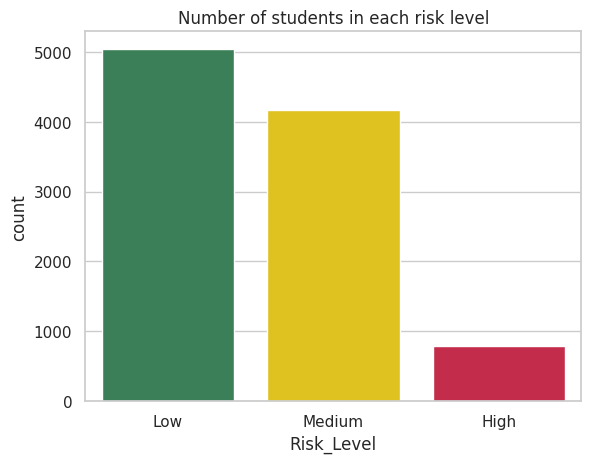

In [ ]:
# Define a custom python function named 'rule_risk' that takes two numeric arguments: 'marks' and 'attendance'

def rule_risk(marks, attendance):
    # Calculate a composite weighted risk score where lower marks contribute 60% and lower attendance contributes 40%
    score = 0.6 * (100 - marks) + 0.4 * (100 - attendance)

    # Check if the calculated risk score is greater than/equal to 40 OR if the student's marks are strictly below 50
    if score >= 40 or marks < 50:
        # Return the string classification "High" for high-risk students meeting either condition
        return "High"

    # Check if the risk score is greater than or equal to 25 for remaining students
    elif score >= 25:
        # Return the string classification "Medium" for moderate-risk students
        return "Medium"

    # Fallback return statement for students with risk scores below 25
    return "Low"

# Apply 'rule_risk' row-by-row (axis=1) using a lambda function passing 'Total_Score' and 'Attendance (%)' to populate a new 'Risk_Level' column
df["Risk_Level"] = df.apply(lambda row: rule_risk(row["Total_Score"], row["Attendance (%)"]), axis=1)

# Pass test inputs (marks = 55, attendance = 62) directly into 'rule_risk' and print the returned risk level alongside verification text
print("Check with the PDF example (attendance 62, marks 55):", rule_risk(55, 62))

# Print a section header text indicating that value counts per risk level category will follow
print("\nHow many students in each risk level:")

# Count the frequency of occurrence for each distinct risk category in 'Risk_Level' and print the results
print(df["Risk_Level"].value_counts())

# Draw a categorical count bar plot of 'Risk_Level' ordering bars as ["Low", "Medium", "High"], mapped to custom colors ("seagreen", "gold", "crimson")
sns.countplot(data=df, x="Risk_Level", hue="Risk_Level", order=["Low", "Medium", "High"], legend=False,
              palette={"Low": "seagreen", "Medium": "gold", "High": "crimson"})

# Set the title text of the current Seaborn count plot figure to "Number of students in each risk level"
plt.title("Number of students in each risk level")

# Render and display the count plot figure on the screen
plt.show()

## Step 5 - Choose the features and prepare the data for ML
A **feature** is an input column the model uses. We remove columns that should not be used:

| Removed | Reason |
|---|---|
| `Student_ID`, names, `Email` | Identifiers - they say nothing about performance |
| `Total_Score`, `Grade` | The risk label is **built from** these. Using them would be cheating (**data leakage**): the model would just copy our rule. |
| `Final_Score` | Taken at the very end. We want an **early-warning system** that works *before* the final exam. |
| `Gender` | Nobody should be labelled "at risk" because of their gender (fairness). |

Then we split the data: **80% to train** the model, **20% to test** it on students it has never seen.
The pipeline fills missing values (median for numbers, most common value for text), scales numbers and one-hot encodes text.

In [ ]:
# Import the function to split datasets into random train and test subsets
from sklearn.model_selection import train_test_split

# Import modules to scale numerical features and one-hot encode categorical features
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import ColumnTransformer to apply different preprocessing pipelines to different columns
from sklearn.compose import ColumnTransformer

# Import Pipeline to sequentially apply a list of transforms and a final estimator
from sklearn.pipeline import Pipeline

# Import SimpleImputer to fill in missing values (NaNs) in the dataset
from sklearn.impute import SimpleImputer


# ==============================================================================
# SECTION 1: FEATURE SELECTION & DROP LEAKAGE / IDENTIFIER COLUMNS
# ==============================================================================

# Define a list of column names that should not be used as input features for training
drop_cols = [
    "Student_ID", "First_Name", "Last_Name", "Email",   # Identifiers (non-predictive unique identifiers)
    "Gender",                                            # Sensitive attribute excluded for algorithmic fairness
    "Total_Score", "Grade", "Final_Score",              # Outcome columns (causes data leakage since risk target is derived from these)
    "Risk_Level"                                         # The target variable label itself
]

# Use a list comprehension to select all DataFrame columns except those listed in drop_cols
features = [c for c in df.columns if c not in drop_cols]

# Create the feature matrix X containing only the allowed predictor columns from the DataFrame
X = df[features]

# Create the target vector y containing the Risk_Level string categories to predict
y = df["Risk_Level"]


# ==============================================================================
# SECTION 2: STRATIFIED TRAIN / TEST SPLIT
# ==============================================================================

# Split feature matrix X and target y into 80% training and 20% testing sets, maintaining class proportions (stratify=y) and fixing random seed (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# ==============================================================================
# SECTION 3: COLUMN TRANSFORMER & PREPROCESSING PIPELINE DESIGN
# ==============================================================================

# Force 'test_preparation_course' to string type to prevent any automated pandas detection issues
X_train = X_train.copy()
X_test = X_test.copy()
X_train["test_preparation_course"] = X_train["test_preparation_course"].astype(str)

# Extract numerical column names, ensuring we exclude text categories explicitly
num_cols = X_train.select_dtypes(include="number").columns.tolist()
if "test_preparation_course" in num_cols:
    num_cols.remove("test_preparation_course")

# Extract all categorical/non-numerical column names
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
if "test_preparation_course" not in cat_cols:
    cat_cols.append("test_preparation_course")

# Define a ColumnTransformer to apply distinct preprocessing pipelines to numerical and categorical features independently
preprocessor = ColumnTransformer(transformers=[
    # Numerical pipeline: imputer replaces NaNs with column median, then StandardScaler normalizes features to zero mean and unit variance
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols),

    # Categorical pipeline: imputer replaces NaNs with most frequent value, then OneHotEncoder creates binary dummy variables (ignoring unseen categories in test)
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

# Print the final list of feature names used for model inputs
print("Features used:", features)

# Print the exact row counts for both the training set and testing set
print(f"Training students: {len(X_train)}   Testing students: {len(X_test)}")

Features used: ['Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'science_score']
Training students: 8000   Testing students: 2000


## Step 6 - Train, compare and evaluate the models
We compare a **baseline** (always guesses the most common level - the minimum bar) with three real algorithms:
Logistic Regression, Decision Tree and Random Forest.

**Two choices that matter:**
1. `class_weight="balanced"` - High-risk students are the **smallest group**. Without this, models mostly guess "Low" or "Medium" and *miss* the students who need help. With it, the model pays more attention to High risk.
2. We pick the best model by **macro F1** (all 3 levels count equally), not plain accuracy, so a model cannot look good just by ignoring the small High-risk group.

**Metrics in plain English** (think of "High risk" as the class we want to catch):
* **Accuracy** - how many students are classified correctly overall
* **Precision** - when the model says "High", how often is it right
* **Recall** - of all truly High-risk students, how many did we catch (the most important metric here)
* **F1-score** - one number balancing precision and recall
* **Confusion matrix** - true level (rows) vs predicted level (columns); the diagonal is correct

                     Accuracy  Macro F1  High-risk recall
Model                                                    
Baseline                 0.50      0.22              0.00
Logistic Regression      0.49      0.43              0.87
Decision Tree            0.46      0.41              0.93
Random Forest            0.50      0.44              0.75

---> Best model: Random Forest

              precision    recall  f1-score   support

         Low       0.67      0.67      0.67      1008
      Medium       0.49      0.25      0.33       834
        High       0.21      0.75      0.33       158

    accuracy                           0.50      2000
   macro avg       0.46      0.56      0.44      2000
weighted avg       0.56      0.50      0.50      2000



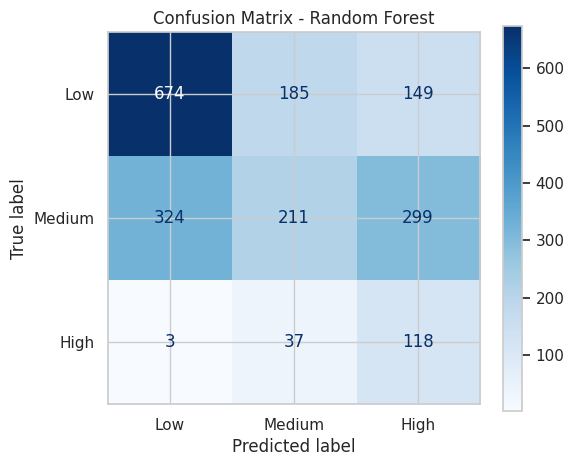

In [ ]:

# Import the DummyClassifier model from scikit-learn to serve as a simple benchmark/baseline
from sklearn.dummy import DummyClassifier

# Import the LogisticRegression algorithm for linear classification modeling
from sklearn.linear_model import LogisticRegression

# Import the DecisionTreeClassifier for tree-based non-linear classification modeling
from sklearn.tree import DecisionTreeClassifier

# Import the RandomForestClassifier ensemble algorithm combining multiple decision trees
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics: overall accuracy, macro-averaged F1 score, and class recall
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Import classification_report to generate comprehensive per-class precision, recall, and F1 metrics
from sklearn.metrics import classification_report

# Import confusion_matrix to compute the table of actual versus predicted class distributions
from sklearn.metrics import confusion_matrix

# Import ConfusionMatrixDisplay to graphically render the confusion matrix table
from sklearn.metrics import ConfusionMatrixDisplay


# ==============================================================================
# SECTION 1: MODEL INITIALIZATION & HYPERPARAMETER DEFINITION
# ==============================================================================

# Define a constant list establishing the specific ordered class labels for risk prediction
LEVELS = ["Low", "Medium", "High"]

# Define a dictionary containing candidate classification models paired with their configuration hyperparameter settings
models = {
    # Baseline dummy model that always predicts the single most frequent class label in y_train
    "Baseline": DummyClassifier(strategy="most_frequent"),

    # Logistic Regression with increased max iterations to reach convergence and class weighting to address imbalance
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),

    # Decision Tree restricted to depth 5 and minimum leaf size 20 to prevent overfitting on training data
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, class_weight="balanced", random_state=42),

    # Random Forest ensemble with 200 trees, parallel execution across all CPU cores (n_jobs=-1), and balanced class weights
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=20, class_weight="balanced",
                                            random_state=42, n_jobs=-1),
}


# ==============================================================================
# SECTION 2: MODEL TRAINING, TESTING, & METRIC AGGREGATION LOOP
# ==============================================================================

# Initialize an empty dictionary to hold trained pipeline objects and their test predictions
trained = {}

# Initialize an empty list to store metric dictionary records for each evaluated model
rows = []

# Iterate over each model name and model instance key-value pair in the models dictionary
for name, model in models.items():
    # Construct an end-to-end Machine Learning Pipeline chaining the preprocessing step to the current classifier
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])

    # Fit the complete pipeline on training features (X_train) and training labels (y_train)
    clf.fit(X_train, y_train)

    # Generate predictions on unseen test set features (X_test) using the fitted pipeline
    y_pred = clf.predict(X_test)

    # Store the fitted pipeline and test set predictions as a tuple in the 'trained' dictionary under the model name key
    trained[name] = (clf, y_pred)

    # Append a dictionary record containing the calculated evaluation metrics for this model to the 'rows' list
    rows.append({
        # Store the current model name string
        "Model": name,

        # Calculate overall accuracy score comparing actual test labels (y_test) with predicted labels (y_pred)
        "Accuracy": accuracy_score(y_test, y_pred),

        # Calculate macro-averaged F1 score (unweighted mean of per-class F1 scores, setting zero_division=0 to prevent division errors)
        "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),

        # Extract the specific recall score for the "High" risk class (proportion of actual High-risk students correctly identified)
        "High-risk recall": recall_score(y_test, y_pred, labels=["High"], average=None, zero_division=0)[0],
    })


# ==============================================================================
# SECTION 3: MODEL COMPARISON & SELECTION
# ==============================================================================

# Convert the list of metric dictionaries into a Pandas DataFrame, set 'Model' as index, round metrics to 2 decimal places, and save to 'comparison'
comparison = pd.DataFrame(rows).set_index("Model").round(2)

# Display the metric comparison summary table on the console
print(comparison)

# Filter out the baseline model, locate the index name of the model achieving the highest Macro F1 score, and store it in 'best_name'
best_name = comparison.drop(index="Baseline")["Macro F1"].idxmax()

# Unpack the best performing pipeline object and its corresponding test predictions from the 'trained' dictionary
best_model, best_pred = trained[best_name]

# Print the name of the winning selected model surrounded by formatting text
print(f"\n---> Best model: {best_name}\n")


# ==============================================================================
# SECTION 4: DETAILED EVALUATION & CONFUSION MATRIX VISUALIZATION
# ==============================================================================

# Print a detailed classification report showing Precision, Recall, and F1-score for each class level (Low, Medium, High)
print(classification_report(y_test, best_pred, labels=LEVELS, zero_division=0))

# Compute the 3x3 confusion matrix array comparing actual test labels with best model predictions ordered by LEVELS
cm = confusion_matrix(y_test, best_pred, labels=LEVELS)

# Create a figure and axis subplot object for rendering the confusion matrix plot with 6x5 inch dimensions
fig, ax = plt.subplots(figsize=(6, 5))

# Create a ConfusionMatrixDisplay object from the matrix array, format as raw integer counts (values_format="d"), and plot on the axis using a blue color map
ConfusionMatrixDisplay(cm, display_labels=LEVELS).plot(ax=ax, cmap="Blues", values_format="d")

# Set the title text of the confusion matrix plot to reflect the winning model's name
ax.set_title(f"Confusion Matrix - {best_name}")

# Render and display the final confusion matrix graphic plot on the screen
plt.show()

**How to read and explain these results (be honest - judges value this):**
* Compare every model with the **Baseline**. If a model is only slightly better, say so.
* Using class weights usually makes **High-risk recall go up** while **overall accuracy and High-risk precision go down** (more false alarms: some students flagged High will turn out to be fine). That is a deliberate trade-off: for an early-warning system, missing a student who needs help is worse than a false alarm. State both numbers (recall and precision for High) when you present.
* **Why can't the model be near-perfect here?** The risk label depends on `Total_Score`, but we hid `Total_Score` and `Final_Score` from the model on purpose (to avoid leakage). If the remaining columns (midterm, quizzes...) hardly relate to `Total_Score` in this dataset (check the heatmap in Step 3), then **attendance is the only real signal**, and that limits how accurate any model can be. This is a property of the data, not a coding mistake.

## Step 7 - Prediction, recommendation and automatic report
**Recommendation rules (simple and explainable):**
* Attendance below **75%** -> improve attendance
* A component score (midterm, assignments, quizzes, projects) in the **lowest 30% of the class** -> advice for that area
* The message gets stronger as the risk level goes up (High -> meet the mentor this week)

`predict_student()` prints the output in the format asked in the PDF. `Marks` is optional: if you know the student's marks, we also show what our rule says, as a cross-check.

In [ ]:
import os

# Safety check: this cell needs the earlier cells to have been run first
for needed in ["df", "features", "best_model", "make_recommendation"]:
    if needed not in globals():
        raise NameError(f"'{needed}' is missing - run all the cells above first (Runtime -> Run all).")

os.makedirs("outputs", exist_ok=True)

# Predict risk for every student
all_pred = best_model.predict(df[features])

# One personalised recommendation per student
recs = [make_recommendation(row["Attendance (%)"], row, risk)
        for (_, row), risk in zip(df.iterrows(), all_pred)]

# Build the report table (astype(str) avoids errors if a name is empty or not text)
report = pd.DataFrame({
    "Student": df["Student_ID"].astype(str) + " - " + df["First_Name"].astype(str) + " " + df["Last_Name"].astype(str),
    "Attendance (%)": df["Attendance (%)"].round(1),
    "Risk": all_pred,
    "Recommendation": recs,
})

# Most urgent first: High -> Medium -> Low, and lowest attendance first inside each level
order = {"High": 0, "Medium": 1, "Low": 2}
report = (report.assign(sort_key=report["Risk"].map(order))
                .sort_values(["sort_key", "Attendance (%)"])
                .drop(columns="sort_key")
                .reset_index(drop=True))

# Save the report (the CSV always works; Excel needs the 'openpyxl' package, which Colab has)
report.to_csv("outputs/student_risk_report.csv", index=False)
try:
    report.to_excel("outputs/student_risk_report.xlsx", index=False)
    print("Report saved in the 'outputs/' folder (CSV and Excel).")
except ImportError:
    print("Report saved as CSV. Excel skipped - run  !pip install openpyxl  and re-run this cell for the .xlsx file.")

print("\nPredicted risk levels:\n", report["Risk"].value_counts())
report.head(10)

Report saved in the 'outputs/' folder (CSV and Excel).

Predicted risk levels:
 Risk
Low       4939
High      2694
Medium    2367
Name: count, dtype: int64


,Student,Attendance (%),Risk,Recommendation
0,S1336 - Ahmed Johnson,50.0,High,Needs urgent academic intervention - meet the ...
1,S1964 - Omar Williams,50.0,High,Needs urgent academic intervention - meet the ...
2,S3755 - Omar Johnson,50.0,High,Needs urgent academic intervention - meet the ...
3,S4281 - Ali Johnson,50.0,High,Needs urgent academic intervention - meet the ...
4,S7423 - Maria Jones,50.0,High,Needs urgent academic intervention - meet the ...
5,S7649 - Omar Brown,50.0,High,Needs urgent academic intervention - meet the ...
6,S8380 - Maria Brown,50.0,High,Needs urgent academic intervention - meet the ...
7,S8917 - Omar Johnson,50.0,High,Needs urgent academic intervention - meet the ...
8,S1116 - Ali Davis,50.1,High,Needs urgent academic intervention - meet the ...
9,S2084 - Emma Jones,50.1,High,Needs urgent academic intervention - meet the ...


In [ ]:
# Create a directory named 'outputs' on disk if it does not already exist, preventing errors using exist_ok=True
os.makedirs("outputs", exist_ok=True)

# Generate risk level predictions for every student in the entire dataset using the trained best model pipeline
all_pred = best_model.predict(df[features])

# Use a list comprehension to generate a personalized recommendation string for each student by pairing row data with predicted risk
recs = [make_recommendation(row["Attendance (%)"], row, risk)
        for (_, row), risk in zip(df.iterrows(), all_pred)]

# Construct a consolidated summary DataFrame containing student names, attendance, predicted risk levels, and generated recommendations
report = pd.DataFrame({
    # Combine Student_ID, First_Name, and Last_Name into a single formatted string identifier column
    "Student": df["Student_ID"].astype(str) + " - " + df["First_Name"] + " " + df["Last_Name"],

    # Extract attendance percentages rounded to 1 decimal place
    "Attendance (%)": df["Attendance (%)"].round(1),

    # Store the array of predicted risk categories ("High", "Medium", "Low")
    "Risk": all_pred,

    # Store the generated custom recommendation text strings
    "Recommendation": recs,
})

# Define a dictionary mapping risk categories to numeric ranks to prioritize high-risk students at the top of the report
order = {"High": 0, "Medium": 1, "Low": 2}

# Sort the report by risk severity first (High -> Medium -> Low) and attendance ascending second, then clean up the temporary sort key and reset row indices
report = (report.assign(sort_key=report["Risk"].map(order))
                .sort_values(["sort_key", "Attendance (%)"])
                .drop(columns="sort_key")
                .reset_index(drop=True))

# Export the ordered risk summary report as a CSV file inside the 'outputs' directory without row indices
report.to_csv("outputs/student_risk_report.csv", index=False)

# Export the ordered risk summary report as an Excel spreadsheet inside the 'outputs' directory without row indices
report.to_excel("outputs/student_risk_report.xlsx", index=False)

# Print a confirmation message indicating that both output files have been successfully written to disk
print("Report saved in the 'outputs/' folder (CSV and Excel).")

# Print a section header for the predicted risk class distribution table
print("\nPredicted risk levels:\n", report["Risk"].value_counts())

# Render and display the top 10 most urgent student records from the sorted report DataFrame
report.head(10)

Report saved in the 'outputs/' folder (CSV and Excel).

Predicted risk levels:
 Risk
Low       4939
High      2694
Medium    2367
Name: count, dtype: int64


,Student,Attendance (%),Risk,Recommendation
0,S1336 - Ahmed Johnson,50.0,High,Needs urgent academic intervention - meet the ...
1,S1964 - Omar Williams,50.0,High,Needs urgent academic intervention - meet the ...
2,S3755 - Omar Johnson,50.0,High,Needs urgent academic intervention - meet the ...
3,S4281 - Ali Johnson,50.0,High,Needs urgent academic intervention - meet the ...
4,S7423 - Maria Jones,50.0,High,Needs urgent academic intervention - meet the ...
5,S7649 - Omar Brown,50.0,High,Needs urgent academic intervention - meet the ...
6,S8380 - Maria Brown,50.0,High,Needs urgent academic intervention - meet the ...
7,S8917 - Omar Johnson,50.0,High,Needs urgent academic intervention - meet the ...
8,S1116 - Ali Davis,50.1,High,Needs urgent academic intervention - meet the ...
9,S2084 - Emma Jones,50.1,High,Needs urgent academic intervention - meet the ...


## Conclusion and limitations
**What we did:** cleaned the data, explored attendance vs marks, defined our own Low/Medium/High risk rule, selected features without leakage, compared four models using suitable metrics, and built a predictor and an automatic report with recommendations.

**Limitations (say these yourself in the presentation):**
1. The risk label is **our own rule** (marks + attendance), not an official one. The model learns to anticipate it from early indicators.
2. Attendance is both part of the rule and an input feature. This is intentional (it is a real early warning sign) but makes accuracy somewhat optimistic.
3. In this dataset attendance and marks are not related, so the model has limited information to work with.
4. The report predicts for all students, including those the model was trained on; in real use you would run it on current students.
5. Recommendations are rule-based and generic; a human mentor should make the final decision.

**Next steps:** tune the models, try Gradient Boosting, use week-by-week attendance, and check fairness across departments.